# Feasibility of True Muonium Photoproduction

## Imports and Definitions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.constants import physical_constants

from importlib import reload
import helperFunctions as hf

In [2]:
# muon mass in [MeV]
muonMass_MeV = physical_constants['muon mass energy equivalent in MeV'][0]

# electron mass in [MeV]
electronMass_MeV = physical_constants['electron mass energy equivalent in MeV'][0]

In [3]:
reload(hf)

<module 'helperFunctions' from '/Users/sivo/Documents/muonium/70_publications/trueMuoniumFeasibility/trueMuonium/helperFunctions.py'>

## Parameters

In [4]:
# initial photon beam energy in [MeV]
photonEnergy = 300

# Lorentz factor of the TM atom
lorentzFactor = photonEnergy/(2*muonMass_MeV)

# relativistic velocity of the TM atom
relVel = np.sqrt(1 - 1/lorentzFactor**2)

In [5]:
# minimal energy in [MeV]
E_th_min = lorentzFactor * (muonMass_MeV - relVel*np.sqrt(muonMass_MeV**2 - electronMass_MeV**2))
E_th_max = lorentzFactor * (muonMass_MeV + relVel*np.sqrt(muonMass_MeV**2 - electronMass_MeV**2))
print(f'E in [{E_th_min:.1f}, {E_th_max:.1f}] MeV')

# maximal longitudinal position in [mm]
z_th_min = -500
z_th_max = 1000
print(f'z in [{z_th_min:.0f}, {z_th_max:.0f}] mm')

E in [43.5, 256.5] MeV
z in [-500, 1000] mm


## Background Rejection

In [6]:
# number of simulated primary photons
Nsim = 4e13

# number of e-/e+ after preselection
# slighly higher than in binned data
Ne = 1852329
Np = 1644504

print(f'Ne = {Ne}')
print(f'Np = {Np}')
print()
print(f'{Ne/4e13:.2e} e-/y')
print(f'{Np/4e13:.2e} e+/y')

Ne = 1852329
Np = 1644504

4.63e-08 e-/y
4.11e-08 e+/y


In [7]:
# load histogrammed data of signal and background
H4D_bkg = np.load('data/bkgH4D.npz')['H4D']
H4D_sig = np.load('data/sigH4D.npz')['H4D']

# load the binning of the histogrammed data
bins = np.load('data/bkgH4D.npz')
bins = [bins['alphaBins'], bins['dPhiBins'], bins['ptBins'], bins['mInvBins']]

In [8]:
# opening angle in [deg]
s0_low = 60; s0_high = 140
s0 = hf.bin_range(bins[0], low=s0_low, high=s0_high)

# azimuthal angle in [deg]
s1_low = 160; s1_high = 200
s1 = hf.bin_range(bins[1], low=s1_low, high=s1_high)

# transverse momentum in [MeV]
s2_low = 0; s2_high = 34
s2 = hf.bin_range(bins[2], low=s2_low, high=s2_high)

# invariant mass in [MeV]
s3_low = 190; s3_high = 230
s3 = hf.bin_range(bins[3], low=s3_low, high=s3_high)

ss = [s0,s1,s2,s3]

Hbkg = H4D_bkg[s0, s1, s2, s3]
Hsig = H4D_sig[s0, s1, s2, s3]

In [9]:
# true positive (signal that survives all cuts)
TP = Hsig.sum()

# false negative (rejected signal events)
FN = H4D_sig.sum() - TP

# accepted signal events / all signal events
sigEff = TP / (TP + FN)
print('SIGNAL')
print(f'signal efficiency:\t{sigEff:.2e}')

print('\nBACKGROUND')
print(f'simulated photons:\t{Nsim:.2e}')
print(f'simulated BG events:\t{Ne*Np:.2e}')

# false positive (background that survives all cuts)
FP = Hbkg.sum()
print(f'\nfalse positive:\t\t{FP:.2e}')

# true negative (rejected background events)
TN = Ne*Np - FP

# accepted background events / all background events
bkgEff = FP / (FP + TN)
print(f'background efficiency:\t{bkgEff:.2e}')
print(f'background rejection: \t{(1-bkgEff):.2e}')

if FP==0:
    print('\nno false positive from simulation!')
    print(f'upper limit on background efficiency: {3/TN:.1e} at 95% C.L.')

SIGNAL
signal efficiency:	9.44e-01

BACKGROUND
simulated photons:	4.00e+13
simulated BG events:	3.05e+12

false positive:		0.00e+00
background efficiency:	0.00e+00
background rejection: 	1.00e+00

no false positive from simulation!
upper limit on background efficiency: 9.8e-13 at 95% C.L.


/var/folders/1r/1tyjjhy95gxfb74qcm8bdf200000gn/T/ipykernel_14355/1913084473.py:19: RuntimeWarning: invalid value encountered in divide
  H_bkg_tmp = H_bkg_tmp / H_bkg_tmp.max()


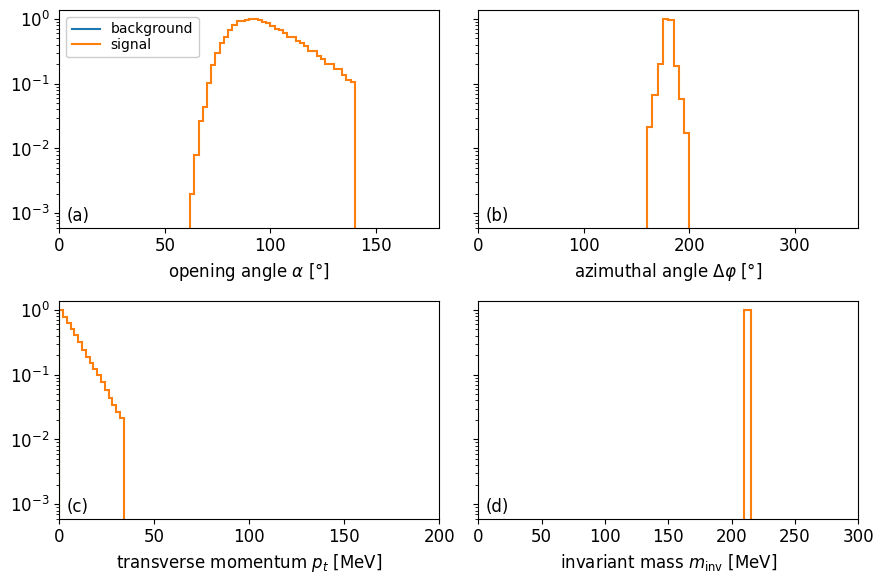

In [13]:
xlabels = [r'opening angle $\alpha$ [°]', 
           r'azimuthal angle $\Delta\varphi$ [°]', 
           r'transverse momentum $p_t$ [MeV]', 
           r'invariant mass $m_\text{inv}$ [MeV]']

subFigLabel = ['(a)', 
               '(b)', 
               '(c)', 
               '(d)']

with plt.rc_context(hf.regu):

    fig, ax = plt.subplots(2, 2, sharey=True, figsize=(9,6))
    ax = ax.flatten()
    
    for k in range(4):
        
        H_bkg_tmp = Hbkg.sum(axis=tuple(i for i in range(Hbkg.ndim) if i!=k))
        H_bkg_tmp = H_bkg_tmp / H_bkg_tmp.max()
        ax[k].stairs(H_bkg_tmp, bins[k][ss[k].start:ss[k].stop+1], color='C0', lw=1.5, label='background')
    
        H_sig_tmp = Hsig.sum(axis=tuple(i for i in range(Hsig.ndim) if i!=k))
        H_sig_tmp = H_sig_tmp / H_sig_tmp.max()
        ax[k].stairs(H_sig_tmp, bins[k][ss[k].start:ss[k].stop+1], color='C1', lw=1.5, label='signal')

        ax[k].text(0.02, 0.03, subFigLabel[k], transform=ax[k].transAxes)
        ax[k].set(xlabel=xlabels[k], xlim=(bins[k][0], bins[k][-1]), yscale='log', ylim=(6e-4, None))

    ax[0].legend()

    fig.tight_layout()
    
    plt.show()

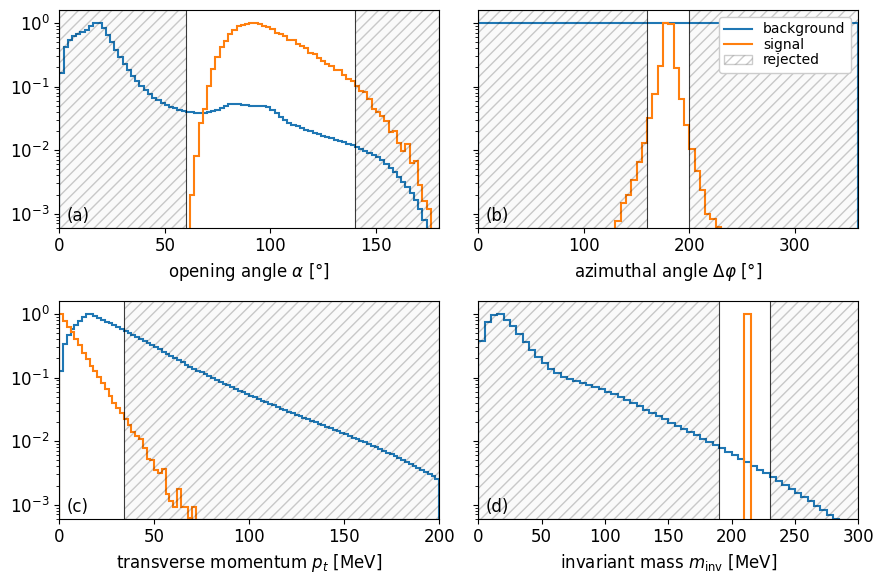

In [12]:
with plt.rc_context(hf.regu):

    fig, ax = plt.subplots(2, 2, sharey=True, figsize=(9,6))
    ax = ax.flatten()
    
    for k in range(4):
        
        H_bkg_tmp = H4D_bkg.sum(axis=tuple(i for i in range(H4D_bkg.ndim) if i!=k))
        H_bkg_tmp = H_bkg_tmp / H_bkg_tmp.max()
        ax[k].stairs(H_bkg_tmp, bins[k], color='C0', lw=1.5, label='background')
    
        H_sig_tmp = H4D_sig.sum(axis=tuple(i for i in range(H4D_sig.ndim) if i!=k))
        H_sig_tmp = H_sig_tmp / H_sig_tmp.max()
        ax[k].stairs(H_sig_tmp, bins[k], color='C1', lw=1.5, label='signal')

        ax[k].text(0.02, 0.03, subFigLabel[k], transform=ax[k].transAxes)
        ax[k].set(xlabel=xlabels[k], xlim=(bins[k][0], bins[k][-1]), yscale='log', ylim=(6e-4, None))

    ax[0].axvline(s0_low, c='C5', ls='-', lw=0.5)
    ax[0].axvspan(bins[0][0], s0_low, color='C5', alpha=0.02, zorder=0)
    ax[0].axvspan(bins[0][0], s0_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[0].axvline(s0_high, c='C5', ls='-', lw=0.5)
    ax[0].axvspan(s0_high, bins[0][-1], color='C5', alpha=0.02, zorder=0)
    ax[0].axvspan(s0_high, bins[0][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)
    
    ax[1].axvline(s1_low, c='C5', ls='-', lw=0.5)
    ax[1].axvspan(bins[1][0], s1_low, color='C5', alpha=0.02, zorder=0)
    ax[1].axvspan(bins[1][0], s1_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[1].axvline(s1_high, c='C5', ls='-', lw=0.5)
    ax[1].axvspan(s1_high, bins[1][-1], color='C5', alpha=0.02, zorder=0)
    ax[1].axvspan(s1_high, bins[1][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)

    ax[2].axvline(s2_low, c='C5', ls='-', lw=0.5)
    ax[2].axvspan(bins[2][0], s2_low, color='C5', alpha=0.02, zorder=0)
    ax[2].axvspan(bins[2][0], s2_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[2].axvline(s2_high, c='C5', ls='-', lw=0.5)
    ax[2].axvspan(s2_high, bins[2][-1], color='C5', alpha=0.02, zorder=0)
    ax[2].axvspan(s2_high, bins[2][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')

    ax[3].axvline(s3_low, c='C5', ls='-', lw=0.5)
    ax[3].axvspan(bins[3][0], s3_low, color='C5', alpha=0.02, zorder=0)
    ax[3].axvspan(bins[3][0], s3_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[3].axvline(s3_high, c='C5', ls='-', lw=0.5)
    ax[3].axvspan(s3_high, bins[3][-1], color='C5', alpha=0.02, zorder=0)
    ax[3].axvspan(s3_high, bins[3][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)   

    ax[1].legend(loc='upper right')

    fig.tight_layout()
    fig.savefig('plots/eventDistributions.png', dpi=300)
    fig.savefig('plots/eventDistributions.pdf')
    
    plt.show()